<a href="https://colab.research.google.com/github/Ajay-s2006/AI_Ml-Assigment/blob/main/ai_ml4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("pankeshpatel/homepricesmultiplevariables")

100%|██████████| 252/252 [00:00<00:00, 414kB/s]

Extracting files...


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# Handle missing values in 'bedrooms' by imputing with the median
# It's good practice to re-calculate the median after each run, if the data changes.
median_bedrooms = df['bedrooms'].median()
df['bedrooms'] = df['bedrooms'].fillna(median_bedrooms)

print("DataFrame after imputing missing 'bedrooms' values:")
display(df.head())

DataFrame after imputing missing 'bedrooms' values:


,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,4.0,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000


In [ ]:
# Define features (X) and target (y)
X = df[['area', 'bedrooms', 'age']]
y = df['price']

print("Features (X) head:")
display(X.head())
print("\nTarget (y) head:")
display(y.head())

Features (X) head:


,area,bedrooms,age
0,2600,3.0,20
1,3000,4.0,15
2,3200,4.0,18
3,3600,3.0,30
4,4000,5.0,8



Target (y) head:


,price
0,550000
1,565000
2,610000
3,595000
4,760000


In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (4, 3)
X_test shape: (2, 3)
y_train shape: (4,)
y_test shape: (2,)


### 1. Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize and train the Linear Regression model
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = linear_reg_model.predict(X_test)

# Evaluate the model
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance:")
print(f"  Mean Absolute Error (MAE): {mae_lr:.2f}")
print(f"  Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"  R-squared (R2): {r2_lr:.2f}")

Linear Regression Performance:
  Mean Absolute Error (MAE): 39608.21
  Mean Squared Error (MSE): 1713617314.55
  R-squared (R2): -29.46


### 2. Decision Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Initialize and train the Decision Tree Regressor model
dt_reg_model = DecisionTreeRegressor(random_state=42)
dt_reg_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_reg_model.predict(X_test)

# Evaluate the model
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Regressor Performance:")
print(f"  Mean Absolute Error (MAE): {mae_dt:.2f}")
print(f"  Mean Squared Error (MSE): {mse_dt:.2f}")
print(f"  R-squared (R2): {r2_dt:.2f}")

Decision Tree Regressor Performance:
  Mean Absolute Error (MAE): 52500.00
  Mean Squared Error (MSE): 2812500000.00
  R-squared (R2): -49.00


### 3. Random Forest Regressor

/tmp/ipykernel_4019/1824247592.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x='Model', y='MAE', data=performance_df, palette='viridis')
/tmp/ipykernel_4019/1824247592.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='Model', y='MSE', data=performance_df, palette='magma')
/tmp/ipykernel_4019/1824247592.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[2], x='Model', y='R2', data=performance_df, palette='plasma')


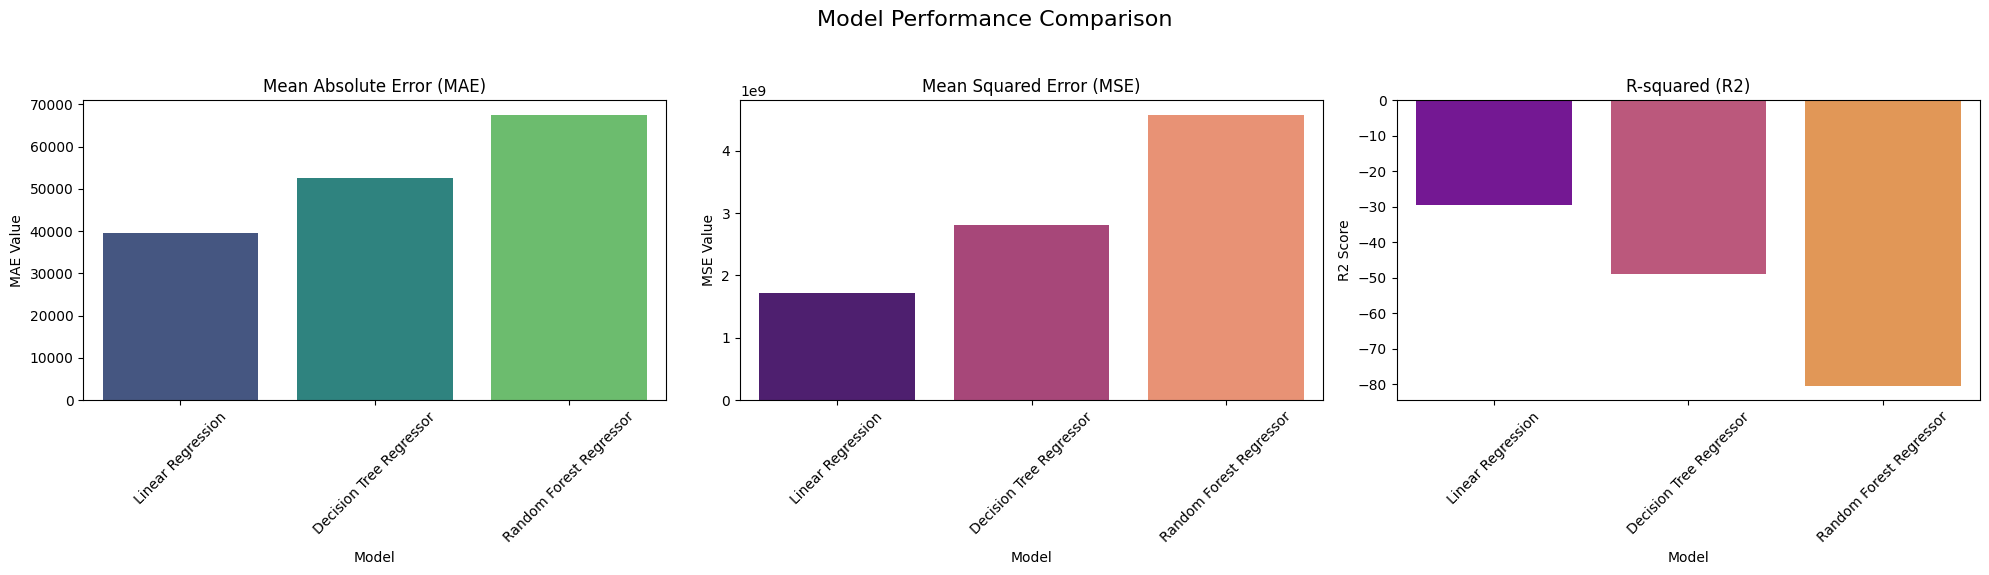

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Gather the performance metrics into a DataFrame for easier plotting
performance_data = {
    'Model': ['Linear Regression', 'Decision Tree Regressor', 'Random Forest Regressor'],
    'MAE': [mae_lr, mae_dt, mae_rf],
    'MSE': [mse_lr, mse_dt, mse_rf],
    'R2': [r2_lr, r2_dt, r2_rf]
}

performance_df = pd.DataFrame(performance_data)

# Create subplots for each metric
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Model Performance Comparison', fontsize=16)

# Bar chart for MAE
sns.barplot(ax=axes[0], x='Model', y='MAE', data=performance_df, palette='viridis')
axes[0].set_title('Mean Absolute Error (MAE)')
axes[0].set_ylabel('MAE Value')
axes[0].tick_params(axis='x', rotation=45)

# Bar chart for MSE
sns.barplot(ax=axes[1], x='Model', y='MSE', data=performance_df, palette='magma')
axes[1].set_title('Mean Squared Error (MSE)')
axes[1].set_ylabel('MSE Value')
axes[1].tick_params(axis='x', rotation=45)

# Bar chart for R2
sns.barplot(ax=axes[2], x='Model', y='R2', data=performance_df, palette='plasma')
axes[2].set_title('R-squared (R2)')
axes[2].set_ylabel('R2 Score')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
rf_reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_reg_model.predict(X_test)

# Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Performance:")
print(f"  Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"  Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"  R-squared (R2): {r2_rf:.2f}")

Random Forest Regressor Performance:
  Mean Absolute Error (MAE): 67600.00
  Mean Squared Error (MSE): 4583450000.00
  R-squared (R2): -80.48


In [ ]:
import os
import pandas as pd

# List files in the downloaded path to identify the CSV file
print("Files in the dataset directory:")
for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

# Assuming the CSV file is directly in the path or a subdirectory
# Let's try to find a common CSV file name or assume a standard one.
# If there are multiple, I might need to ask for clarification.

# A common name might be 'homeprices.csv' or similar.
# For now, let's assume there's one CSV and try to load it.
# I will search for the first .csv file found in the directory.
csv_files = [os.path.join(root, file) for root, dirs, files in os.walk(path) for file in files if file.endswith('.csv')]

if csv_files:
    data_file_path = csv_files[0]
    print(f"\nLoading data from: {data_file_path}")
    df = pd.read_csv(data_file_path)
    print("\nFirst 5 rows of the dataset:")
    display(df.head())
else:
    print("No CSV files found in the dataset directory.")

Files in the dataset directory:
/root/.cache/kagglehub/datasets/pankeshpatel/homepricesmultiplevariables/versions/1/homeprices.csv

Loading data from: /root/.cache/kagglehub/datasets/pankeshpatel/homepricesmultiplevariables/versions/1/homeprices.csv

First 5 rows of the dataset:


,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,NaN,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000
